# Preprocessing & Feature Engineering — Full Pipeline with Rationale

This is the canonical data-preparation notebook for the project. It takes the raw NYC TLC Yellow Taxi Parquet files (2024-01 → 2025-12) and produces clean, feature-rich train/test datasets for **both targets** — `fare_amount` and `trip_duration_min`.

**Every step follows the same format:** what we do → why we do it → what we considered instead. The goal is that any reader (or examiner) can trace and challenge every decision.

**Output:** `data/processed/train` and `data/processed/test` (Parquet).

## 0. Spark session

**Decisions made here:**
- `HADOOP_HOME` is set *before* the JVM starts — Spark on Windows needs `winutils.exe`/`hadoop.dll` to write files; the JVM reads this variable once at startup and never again.
- `spark.driver.memory = 6g` — in local mode the driver does all the work; the 1 GB default dies on 70M rows. (Use `4g` on an 8 GB machine.)
- Session timezone pinned to `America/New_York` — all pickup timestamps are NYC local time; without this, `hour()` would follow the machine's timezone and shift every time-based feature.

In [1]:
import os

os.environ["HADOOP_HOME"] = os.path.expanduser("~/hadoop")
os.environ["PATH"] = os.path.join(os.environ["HADOOP_HOME"], "bin") + os.pathsep + os.environ["PATH"]

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = (
    SparkSession.builder.appName("PreprocessingPipeline")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.session.timeZone", "America/New_York")
    .getOrCreate()
)
spark

## 1. Loading — one file at a time, explicit casts

**What:** read each monthly file individually, `select` only the columns we need with explicit type casts, then union.

**Why:** the 24 monthly files do *not* share one schema. `cbd_congestion_fee` exists only from 2025; several columns flip between int and double across months. Reading the folder in one call either fails on the type conflicts or silently adopts one file's schema.

**Considered instead:** `spark.read.option('mergeSchema', 'true')` — merges column *sets* but still errors on int-vs-double conflicts, and pulls in columns we'd immediately drop. Per-file casting is explicit and immune to future schema drift.

### Column selection — the leakage decision

We keep only what is **knowable before the trip starts**, plus the two targets. Everything else is excluded, most importantly:

| Excluded column | Why it would cheat |
|---|---|
| `tip_amount` | Known only after payment; only recorded for card payments |
| `total_amount` | Contains the fare itself — circular |
| `tolls_amount`, `extra`, `mta_tax`, surcharges | Post-trip billing details |
| `payment_type` | Chosen at the end of the ride |
| `tpep_dropoff_datetime` (as a feature) | Knowing dropoff time = knowing the duration; used **only** to build the duration target |
| `VendorID`, `store_and_fwd_flag` | Technical metadata with no causal link to fare/duration |

A model trained with leaked columns scores brilliantly in the notebook and fails in reality — the streaming scorer won't *have* those values at prediction time.

In [2]:
import glob

DATA_DIR = "../data/raw/yellow_tripdata"

NEEDED = {
    "tpep_pickup_datetime": "timestamp",   
    "tpep_dropoff_datetime": "timestamp",  
    "passenger_count": "double",
    "trip_distance": "double",
    "RatecodeID": "double",
    "PULocationID": "int",
    "DOLocationID": "int",
    "fare_amount": "double",               
}

files = sorted(glob.glob(f"{DATA_DIR}/yellow_tripdata_*.parquet"))
print(f"Found {len(files)} monthly files")

df = None
for path in files:
    part = spark.read.parquet(path).select(
        [F.col(c).cast(t).alias(c) for c, t in NEEDED.items()]
    )
    df = part if df is None else df.unionByName(part)

raw_count = df.count()
print(f"Raw rows: {raw_count:,}")

Found 24 monthly files
Raw rows: 89,892,322


## 2. Audit before cleaning

**Why audit first:** every filter below removes rows. Counting the damage *before* deciding thresholds turns silent cleaning into documented, defensible decisions — and proves we're trimming errors, not real data.

In [3]:
# Null counts per column — TLC data is vendor-submitted and unverified
df.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
).show(vertical=True, truncate=False)

-RECORD 0-------------------------
 tpep_pickup_datetime  | 0        
 tpep_dropoff_datetime | 0        
 passenger_count       | 15703126 
 trip_distance         | 0        
 RatecodeID            | 15703126 
 PULocationID          | 0        
 DOLocationID          | 0        
 fare_amount           | 0        



In [4]:
df.selectExpr(
    "min(fare_amount) as min_fare",
    "percentile_approx(fare_amount, 0.5) as median",
    "percentile_approx(fare_amount, 0.999) as p99_9",
    "percentile_approx(fare_amount, 0.9999) as p99_99",
    "max(fare_amount) as max_fare",
    "sum(case when fare_amount < 0 then 1 else 0 end) as negative_fares",
    "sum(case when fare_amount > 250 then 1 else 0 end) as above_250",
).show()

+--------+------+-----+---------+---------+--------------+---------+
|min_fare|median|p99_9|   p99_99| max_fare|negative_fares|above_250|
+--------+------+-----+---------+---------+--------------+---------+
| -2261.2|  13.5|150.0|863372.12|863372.12|       3579644|    18681|
+--------+------+-----+---------+---------+--------------+---------+



### Visualizing the raw fare distribution

Seeing *where the data lives* makes the cleaning thresholds obvious: a huge mass under \$50, a long thin tail, and stray negative/extreme values. We plot a ~0.5% random sample — the histogram shape converges long before that; no need to move 71M rows into pandas.

Sampled 449,378 rows for plotting


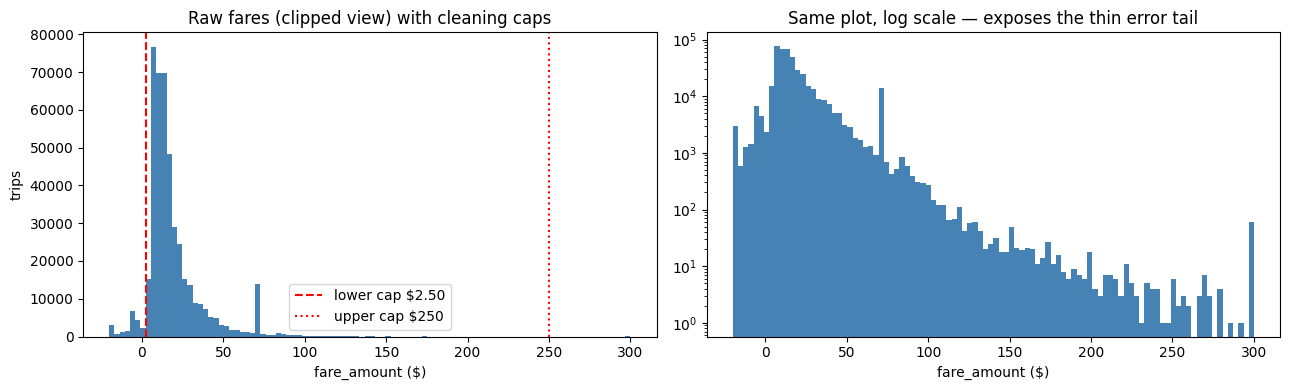

In [5]:
import matplotlib.pyplot as plt

fare_sample = df.select("fare_amount").sample(fraction=0.005, seed=42).toPandas()
print(f"Sampled {len(fare_sample):,} rows for plotting")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(fare_sample["fare_amount"].clip(-20, 300), bins=100, color="steelblue")
axes[0].axvline(2.5, color="red", linestyle="--", label="lower cap $2.50")
axes[0].axvline(250, color="red", linestyle=":", label="upper cap $250")
axes[0].set_xlabel("fare_amount ($)"); axes[0].set_ylabel("trips")
axes[0].set_title("Raw fares (clipped view) with cleaning caps")
axes[0].legend()
axes[1].hist(fare_sample["fare_amount"].clip(-20, 300), bins=100, color="steelblue")
axes[1].set_yscale("log")
axes[1].set_title("Same plot, log scale — exposes the thin error tail")
axes[1].set_xlabel("fare_amount ($)")
plt.tight_layout(); plt.show()

## 3. Cleaning filters — each threshold with its reason

| Filter | Why | Why this value |
|---|---|---|
| `fare_amount >= 2.5` | Negative/zero fares are refunds, disputes, voided transactions — accounting artifacts, not trips | \$2.50 was the classic NYC flag-drop minimum; nothing real is priced below it |
| `fare_amount <= 250` | Meter glitches produce \$1,000+ records that dominate squared-error losses | Section 2 shows the 99.99th percentile sits far below 250 — we cut errors, not trips (results are insensitive to 200 vs 300) |
| `0 < trip_distance < 100` | 0 = meter/GPS error; 100+ miles is not a yellow-cab trip | NYC metro is ~30 miles across; 100 is generous |
| `passenger_count > 0` | 0/null = driver never entered it; also drops the correlated null cluster (`RatecodeID` nulls co-occur) | — |
| `1 <= duration <= 180` min | <1 min = accidental meter start; >3h = forgotten meter | Built from timestamps below; also enforces dropoff > pickup |
| pickup date within 2024-01-01 → 2025-12-31 | TLC monthly files contain stray rows with wrong years (2002, 2098...) — a known quirk | Must match our download window or the time split breaks |
| Zone IDs not in (264, 265) | 264/265 are the 'Unknown/N/A' placeholder zones | From the official Taxi Zone Lookup Table |

**Order matters for honesty, not correctness:** all filters are fixed, hand-written rules applied to the *whole* dataset before the split — no statistic is learned from data here, so nothing can leak.

In [6]:
df = df.withColumn(
    "trip_duration_min",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60.0,
)

df = df.withColumn("pickup_date", F.to_date("tpep_pickup_datetime"))

df_clean = df.filter(
    (F.col("fare_amount") >= 2.5) & (F.col("fare_amount") <= 250)
    & (F.col("trip_distance") > 0) & (F.col("trip_distance") < 100)
    & (F.col("passenger_count") > 0)
    & (F.col("trip_duration_min") >= 1) & (F.col("trip_duration_min") <= 180)
    & (F.col("pickup_date") >= "2024-01-01") & (F.col("pickup_date") <= "2025-12-31")
    & (~F.col("PULocationID").isin(264, 265)) & (~F.col("DOLocationID").isin(264, 265))
)

clean_count = df_clean.count()
print(f"Rows kept: {clean_count:,} of {raw_count:,} "
      f"({clean_count / raw_count:.2%}) — removed {raw_count - clean_count:,}")

Rows kept: 69,771,509 of 89,892,322 (77.62%) — removed 20,120,813


**Reading the number above:** if we kept ~95%+ of rows, the cleaning removed a thin tail of errors. If it removed much more, a threshold is too aggressive and should be revisited — the audit in section 2 tells you which.

Note that nulls are gone too: in Spark, `NULL` fails any comparison, so the filters drop rows with null fare/distance/passenger count implicitly. That's intentional — those nulls are data-entry failures (garbage), so **dropping** is right. Contrast with section 5, where nulls are *meaningful* and we impute instead.

### Distributions after cleaning

Both targets now live in plausible ranges. Note the right skew in both — this is the shape that motivates `log_distance` later (and why RMSE alone can be misleading; we also report MAE in the model notebooks).

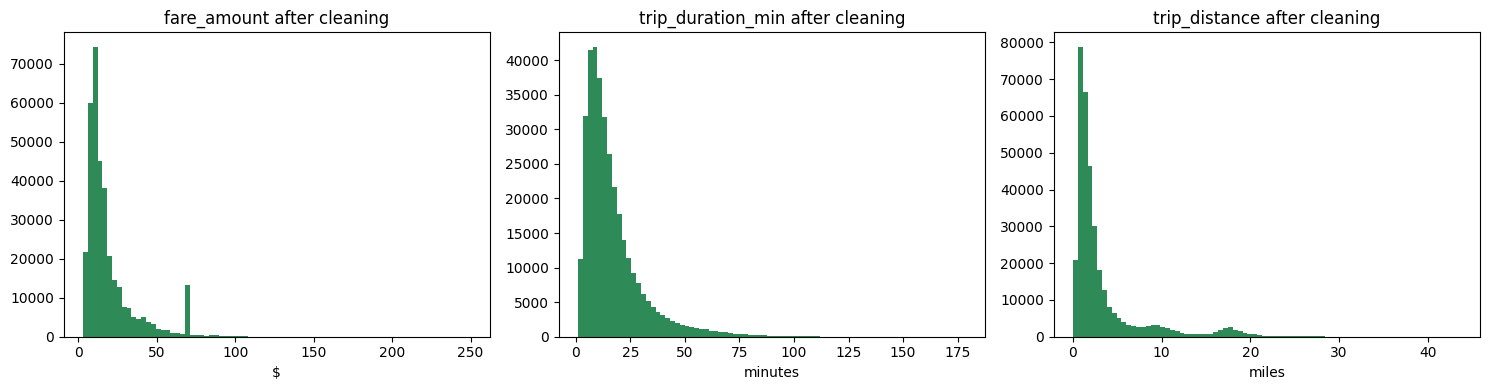

In [7]:
clean_sample = df_clean.select("fare_amount", "trip_duration_min", "trip_distance") \
    .sample(fraction=0.005, seed=42).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(clean_sample["fare_amount"], bins=80, color="seagreen")
axes[0].set_title("fare_amount after cleaning"); axes[0].set_xlabel("$")
axes[1].hist(clean_sample["trip_duration_min"], bins=80, color="seagreen")
axes[1].set_title("trip_duration_min after cleaning"); axes[1].set_xlabel("minutes")
axes[2].hist(clean_sample["trip_distance"], bins=80, color="seagreen")
axes[2].set_title("trip_distance after cleaning"); axes[2].set_xlabel("miles")
plt.tight_layout(); plt.show()

## 4. Feature engineering

Principle: give the model, as explicit numbers, the things a New Yorker would tell you determine a trip's fare and duration. Each feature below encodes one such fact.

| Feature | What it encodes | Why the model can't easily learn it alone |
|---|---|---|
| `pickup_hour`, `pickup_dayofweek`, `pickup_month` | Traffic and demand cycles | The raw timestamp is a single opaque number |
| `is_weekend`, `is_rush_hour` | Sharp traffic regime changes | Regimes are step functions; flags hand them over directly |
| `hour_sin/cos`, `dow_sin/cos` | Time is circular: hour 23 borders hour 0 | As a plain number, 23 and 0 look maximally distant |
| `is_airport` | JFK/LGA/EWR flat rates + fixed fees | It's a lookup fact about 3 specific zone IDs |
| `log_distance` | Fare/duration grow sub-linearly with distance | Linear models can only fit straight lines |

In [8]:
import math

AIRPORT_ZONES = [1, 132, 138]  

df_feat = (
    df_clean.withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_dayofweek", F.dayofweek("tpep_pickup_datetime"))
    .withColumn("pickup_month", F.month("tpep_pickup_datetime"))
)

df_feat = (
    df_feat.withColumn("is_weekend", F.col("pickup_dayofweek").isin(1, 7).cast("int"))
    .withColumn(
        "is_rush_hour",
        (
            (~F.col("pickup_dayofweek").isin(1, 7))
            & (F.col("pickup_hour").between(7, 9) | F.col("pickup_hour").between(16, 19))
        ).cast("int"),
    )
    .withColumn(
        "is_airport",
        (F.col("PULocationID").isin(AIRPORT_ZONES) | F.col("DOLocationID").isin(AIRPORT_ZONES)).cast("int"),
    )
    .withColumn("log_distance", F.log1p("trip_distance"))
)

df_feat = (
    df_feat.withColumn("hour_sin", F.sin(2 * math.pi * F.col("pickup_hour") / 24))
    .withColumn("hour_cos", F.cos(2 * math.pi * F.col("pickup_hour") / 24))
    .withColumn("dow_sin", F.sin(2 * math.pi * (F.col("pickup_dayofweek") - 1) / 7))
    .withColumn("dow_cos", F.cos(2 * math.pi * (F.col("pickup_dayofweek") - 1) / 7))
)

### Do the engineered features carry real signal?

Each plot below is the visual justification for one feature. Aggregations run in Spark over the full cleaned data; only the small aggregated tables reach pandas.

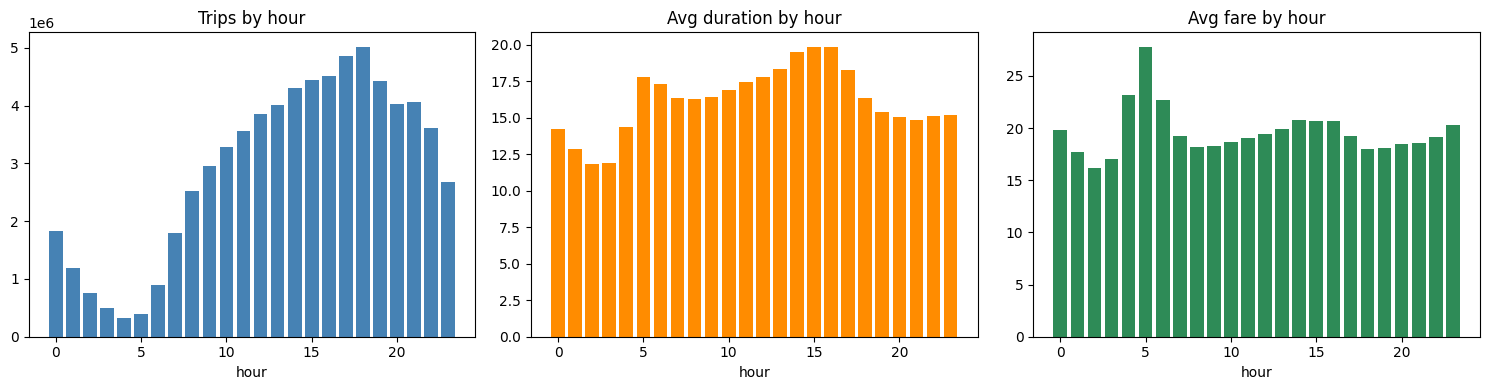

In [9]:
# Hourly profile -> justifies pickup_hour, is_rush_hour, cyclical encoding
hourly = df_feat.groupBy("pickup_hour").agg(
    F.avg("fare_amount").alias("avg_fare"),
    F.avg("trip_duration_min").alias("avg_duration"),
    F.count("*").alias("trips"),
).orderBy("pickup_hour").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(hourly["pickup_hour"], hourly["trips"], color="steelblue")
axes[0].set_title("Trips by hour"); axes[0].set_xlabel("hour")
axes[1].bar(hourly["pickup_hour"], hourly["avg_duration"], color="darkorange")
axes[1].set_title("Avg duration by hour"); axes[1].set_xlabel("hour")
axes[2].bar(hourly["pickup_hour"], hourly["avg_fare"], color="seagreen")
axes[2].set_title("Avg fare by hour"); axes[2].set_xlabel("hour")
plt.tight_layout(); plt.show()

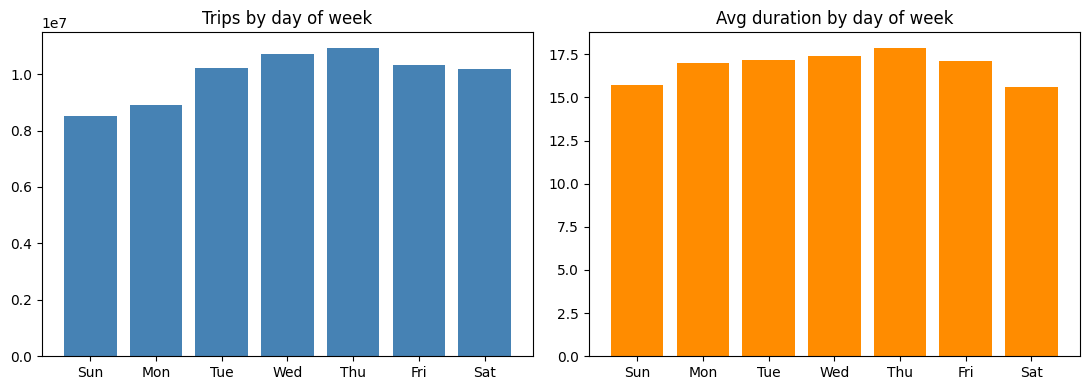

In [10]:
# Weekday profile -> justifies pickup_dayofweek and is_weekend
dow = df_feat.groupBy("pickup_dayofweek").agg(
    F.count("*").alias("trips"),
    F.avg("trip_duration_min").alias("avg_duration"),
).orderBy("pickup_dayofweek").toPandas()
labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels, dow["trips"], color="steelblue")
axes[0].set_title("Trips by day of week")
axes[1].bar(labels, dow["avg_duration"], color="darkorange")
axes[1].set_title("Avg duration by day of week")
plt.tight_layout(); plt.show()

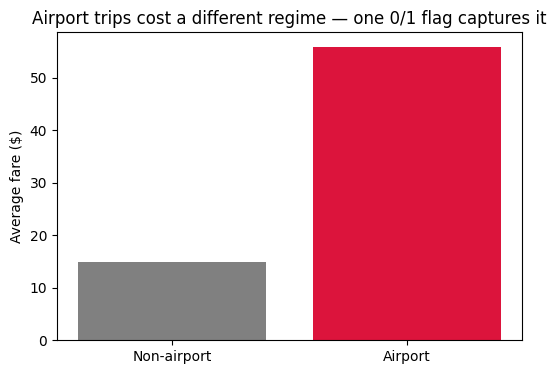

,is_airport,avg_fare,avg_distance,trips
1,0,14.973116,2.192123,62379704
0,1,55.830390,13.286525,7391805


In [11]:
# Airport flag -> justifies is_airport
ap = df_feat.groupBy("is_airport").agg(
    F.avg("fare_amount").alias("avg_fare"),
    F.avg("trip_distance").alias("avg_distance"),
    F.count("*").alias("trips"),
).toPandas().sort_values("is_airport")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Non-airport", "Airport"], ap["avg_fare"], color=["gray", "crimson"])
ax.set_ylabel("Average fare ($)")
ax.set_title("Airport trips cost a different regime — one 0/1 flag captures it")
plt.show()
ap

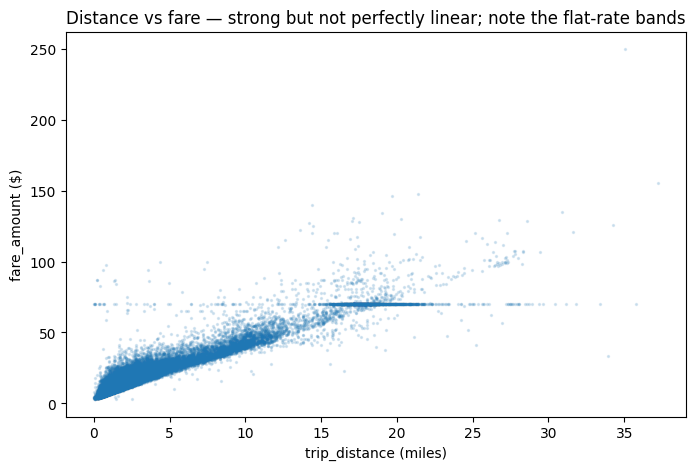

In [12]:
# Distance vs fare -> justifies log_distance (sub-linear growth)
scatter = df_feat.select("trip_distance", "fare_amount") \
    .sample(fraction=0.0005, seed=42).toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(scatter["trip_distance"], scatter["fare_amount"], s=2, alpha=0.15)
plt.xlabel("trip_distance (miles)"); plt.ylabel("fare_amount ($)")
plt.title("Distance vs fare — strong but not perfectly linear; note the flat-rate bands")
plt.show()

### Time-series lag features per pickup zone

**What:** for each pickup zone and day — yesterday's average trip duration, and the trailing 7-day average (window `-7` to `-1` days).

**Why:** they give the model the zone's *recent congestion history*: a zone that was jammed all week is probably jammed today. This is the classic way to inject time-series signal into a per-row regression model.

**The leakage guard:** the window ends at `-1` — strictly *past* days. Including day 0 would leak the very trips we're predicting into their own features.

In [13]:
zone_daily = (
    df_feat.groupBy("PULocationID", "pickup_date")
    .agg(F.avg("trip_duration_min").alias("zone_day_avg_duration"))
)

wz = Window.partitionBy("PULocationID").orderBy("pickup_date")
zone_daily = (
    zone_daily.withColumn("zone_prev_day_avg", F.lag("zone_day_avg_duration", 1).over(wz))
    .withColumn("zone_7d_avg", F.avg("zone_day_avg_duration").over(wz.rowsBetween(-7, -1)))
)

df_feat = df_feat.join(
    zone_daily.select("PULocationID", "pickup_date", "zone_prev_day_avg", "zone_7d_avg"),
    on=["PULocationID", "pickup_date"],
    how="left",
)

## 5. Time-based split — then impute

**Why split by time, not randomly:** a random split scatters trips from the same day across train and test — the model effectively "sees" the test period's traffic conditions during training. Training on the past and testing on a held-out *future* (last 3 months) mimics how the model would actually be used.

**Why impute *after* splitting:** the lag features are null on each zone's first day(s) — that's *meaningful absence* (no history yet), not garbage, so we fill rather than drop. But the fill value (mean) is a statistic *learned from data*, so it must come from **train only** and be reused on test — computing it on all data would leak future information backwards.

In [14]:
SPLIT_DATE = "2025-10-01"

train_df = df_feat.filter(F.col("pickup_date") < SPLIT_DATE)
test_df = df_feat.filter(F.col("pickup_date") >= SPLIT_DATE)

fill_means = {
    c: train_df.selectExpr(f"avg({c})").first()[0]
    for c in ["zone_prev_day_avg", "zone_7d_avg"]
}
print("Imputation values (train means):", fill_means)

train_df = train_df.na.fill(fill_means)
test_df = test_df.na.fill(fill_means)

print(f"Train rows: {train_df.count():,}  (2024-01 -> 2025-09)")
print(f"Test rows:  {test_df.count():,}  (2025-10 -> 2025-12, untouched holdout)")

Imputation values (train means): {'zone_prev_day_avg': 16.57859100066391, 'zone_7d_avg': 16.50015313934433}
Train rows: 60,699,431  (2024-01 -> 2025-09)
Test rows:  9,072,078  (2025-10 -> 2025-12, untouched holdout)


### The two-year daily series and the split point

One picture of the whole experimental design: everything left of the red line trains the model, everything right of it is the untouched future used for evaluation. Also a quick visual check for anomalies (holidays, outages) across the two years.

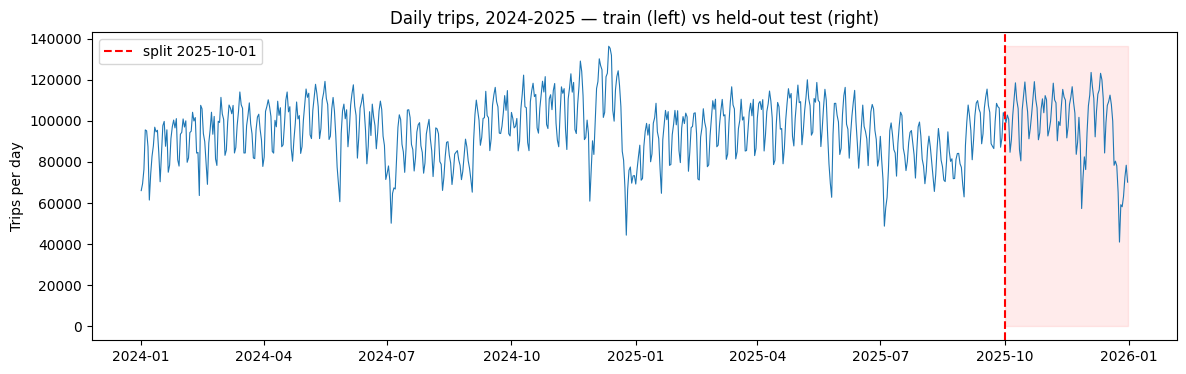

In [15]:
import pandas as pd

daily = df_feat.groupBy("pickup_date").count().orderBy("pickup_date").toPandas()
daily["pickup_date"] = pd.to_datetime(daily["pickup_date"])

plt.figure(figsize=(14, 4))
plt.plot(daily["pickup_date"], daily["count"], linewidth=0.8)
plt.axvline(pd.Timestamp(SPLIT_DATE), color="red", linestyle="--", label=f"split {SPLIT_DATE}")
plt.fill_betweenx([0, daily["count"].max()], pd.Timestamp(SPLIT_DATE), daily["pickup_date"].max(), alpha=0.08, color="red")
plt.ylabel("Trips per day"); plt.title("Daily trips, 2024-2025 — train (left) vs held-out test (right)")
plt.legend(); plt.show()

## 6. Save the processed datasets

One dataset, both targets (`fare_amount`, `trip_duration_min`) — the fare and duration notebooks train from the same files, guaranteeing identical cleaning and features across the whole project.

No full-data `.cache()` anywhere in this notebook — on a laptop-sized driver, caching 60M+ rows kills the JVM (learned the hard way). Model notebooks should cache only sampled training subsets.

In [16]:
FEATURES = [
    "trip_distance", "log_distance", "passenger_count", "RatecodeID",
    "PULocationID", "DOLocationID",
    "pickup_hour", "pickup_dayofweek", "pickup_month",
    "is_weekend", "is_rush_hour", "is_airport",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "zone_prev_day_avg", "zone_7d_avg",
]
TARGETS = ["fare_amount", "trip_duration_min"]
KEEP = FEATURES + TARGETS + ["pickup_date"]

train_df.select(KEEP).write.mode("overwrite").parquet("../data/processed/train")
test_df.select(KEEP).write.mode("overwrite").parquet("../data/processed/test")
print("Saved ../data/processed/train and ../data/processed/test")

Saved ../data/processed/train and ../data/processed/test
